### Compare simulations

Notebook to read in a number of `sww` files and compare (plot) stage time series and flow through cross section near Merimbula bridge.

First import important modules, set up graphics, and define two useful functions.

In [16]:
%load_ext autoreload
%autoreload 2

import project
import anuga
import pandas as pd

import numpy as np
import os
import matplotlib.pyplot as plt

%matplotlib inline

# Allow inline jshtml animations
from matplotlib import rc
rc('animation', html='jshtml')

def open_sww_file(swwfile: str, gauge_x: np.ndarray, gauge_y: np.ndarray, verbose: bool = False) -> tuple[anuga.SWW_plotter, list[int]]:
    """
    Open an SWW file and return the plotter object and gauge IDs.
    
    Args:
        swwfile: Path to the SWW file
        verbose: Whether to print debug information
        
    Returns:
        tuple containing:
            - splotter: SWW_plotter object
            - gauge_ids: list of triangle IDs for each gauge location
    """
    splotter = anuga.SWW_plotter(swwfile)

    #splotter.filename = swwfile

    starttime = splotter.starttime
    dt = pd.to_datetime(starttime, unit='s')
    if verbose:
        print(f'Start time: {dt}')

    # Convert to absolute coordinates
    xc = splotter.xc + splotter.xllcorner
    yc = splotter.yc + splotter.yllcorner

    gauge_ids = []
    for row in zip(gauge_x, gauge_y):
        tid = np.argmin((xc-row[0])**2 + (yc-row[1])**2)
        if verbose:
            print(f'Gauge at ({row[0]:.1f}, {row[1]:.1f}) assigned to triangle {tid}')
        gauge_ids.append(tid)

    return splotter, gauge_ids



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Check for sww files

In [17]:
ls -lh *.sww

-rw-r--r-- 1 steve steve 433M Feb  6 11:54 template_sept_2003_43200_weeds_20260128_144153.sww


Read specified sww files, create associated SWW_plotters, and read in gauge locations 

In [18]:
verbose = False

# Set up the sww files to compare
swwfiles = [
            #'template_sept_2003_43200_weeds_20251202_202802.sww',
            #'template_sept_2003_17156_no_exterior_tags_weeds_20251210_140515.sww',
            #'template_sept_2003_43200_weeds_20260118_114652.sww',
            'template_sept_2003_43200_weeds_20260128_144153.sww',
            ]

num_of_triangles = []
for swwfile in swwfiles:
    num_of_triangles.append(int(swwfile.split('_')[3]))

gauge_location = pd.read_csv(project.gauge_filename)
gauge_x = gauge_location['easting'].to_numpy()
gauge_y = gauge_location['northing'].to_numpy()

splotters = []
gauge_id_list = []

for n, swwfile in enumerate(swwfiles):
    splotter, gauge_ids = open_sww_file(swwfile, gauge_x, gauge_y, verbose=verbose)
    splotters.append(splotter)
    gauge_id_list.append(gauge_ids) 


# polyline at bridge
polyline = [[759205.0-10, 5912912+10],
            [759205.0+45, 5912912-30]]


polygon = [[759205.0-20, 5912912],  
           [759205.0+45, 5912912-40],
           [759205.0+55, 5912912-20],
           [759205.0+5, 5912912+40]]

Figure files for each frame will be stored in _plot


Plot Stage and Mesh near Merimbula Bridge

Gauge gauge4 at (759205.0, 5912912.0)
Triangles intersecting polygon: [ 13 139 191 202 213 687 697 761 766 767 771 776 778 831 851]


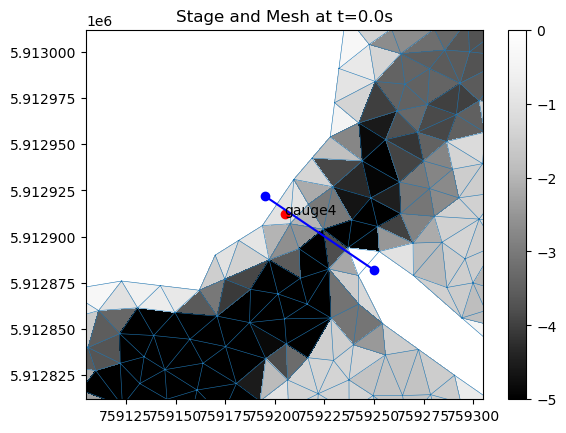

In [19]:
splotter = splotters[0]
tid = 0

plt.tripcolor(splotter.triang,
              #facecolors = splotter.stage[tid,:],
              facecolors = splotter.elev[:],
              cmap='Greys_r',
              vmin= -5,
              vmax= 0.0
              )
plt.triplot(splotter.triang, linewidth = 0.4)
plt.colorbar()
plt.title(f"Stage and Mesh at t={splotter.time[tid]}s")
plt.scatter(gauge_x, gauge_y, color='red')
#for i in range(8):
for i in range(3,4):
    plt.annotate(gauge_location['name'][i], [gauge_x[i], gauge_y[i]])
    print(f'Gauge {gauge_location["name"][i]} at ({gauge_x[i]}, {gauge_y[i]})')

triangle_ids = splotter.get_triangles_inside_polygon(polygon)
print(f'Triangles intersecting polygon: {triangle_ids}')

plt.xlim(759205-100, 759205.0+100)
plt.ylim(5912912-100, 5912912+100)

#plt.scatter([759205.0-10, 759205.0+45], [5912912+10, 5912912-30], color='blue')
plt.scatter([polyline[0][0], polyline[1][0]], [polyline[0][1], polyline[1][1]], color='blue')
plt.plot([polyline[0][0], polyline[1][0]], [polyline[0][1], polyline[1][1]], color='blue')
# plt.plot([polygon[0][0], polygon[1][0], polygon[2][0], polygon[3][0], polygon[0][0]],
#          [polygon[0][1], polygon[1][1], polygon[2][1], polygon[3][1], polygon[0][1]], color='green')
# for tid in triangle_ids:
#     xcentroid = splotter.xc[tid] + splotter.xllcorner
#     ycentroid = splotter.yc[tid] + splotter.yllcorner
#     plt.scatter(xcentroid, ycentroid, color='orange')
plt.show()


In [20]:
splotter.elev[triangle_ids]

array([-0.98, -1.99, -2.55, -5.59, -4.96, -3.79, -5.04, -2.23, -3.02,
        4.06, -2.15, -5.13, -1.31, -0.98, -3.02], dtype=float32)

Text(0.5, 1.0, 'Elevation and Mesh at t=0.0s')

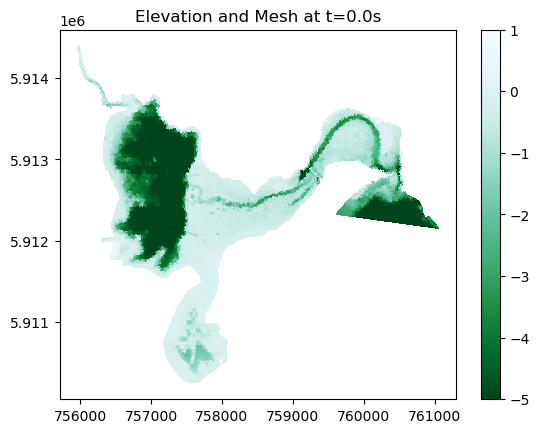

In [21]:
splotter = splotters[0]
tid = 0

plt.tripcolor(splotter.triang,
              facecolors = splotter.elev[:],
              cmap='BuGn_r',
              vmin= -5,
              vmax= 1.0
              )
#plt.triplot(splotter.triang, linewidth = 0.1)
plt.colorbar()
plt.title(f"Elevation and Mesh at t={splotter.time[tid]}s")
#plt.scatter(gauge_x, gauge_y, color='red')

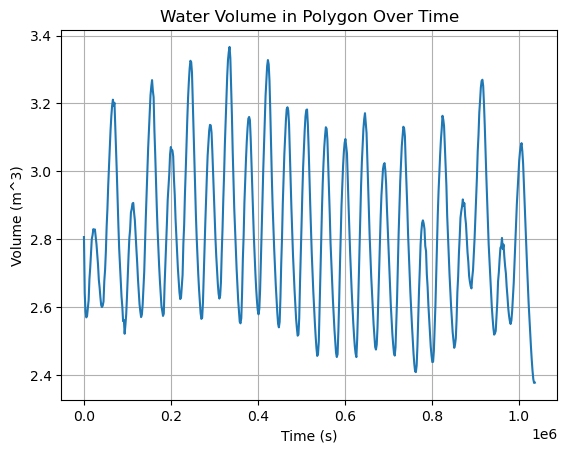

In [22]:
splotter = splotters[0]
volume = splotter.water_volume(per_unit_area=True, polygon=polygon)

plt.plot(splotter.time, volume)
plt.xlabel('Time (s)')
plt.ylabel('Volume (m^3)')
plt.title('Water Volume in Polygon Over Time')
plt.grid()
plt.show()

Compare flow through cross sesction

/tmp/ipykernel_102639/111425904.py:13: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  flow = pd.read_csv(filename, header=None, delim_whitespace=True)


              0          1
0      8.542361  154.69870
1      8.552361  152.69740
2      8.562361  150.69640
3      8.572361  148.69560
4      8.582361  146.69520
...         ...        ...
1351  22.052361  -94.74329
1352  22.062361  -98.71304
1353  22.072361 -102.68750
1354  22.082361 -106.66510
1355  22.092361 -110.64430

[1356 rows x 2 columns]


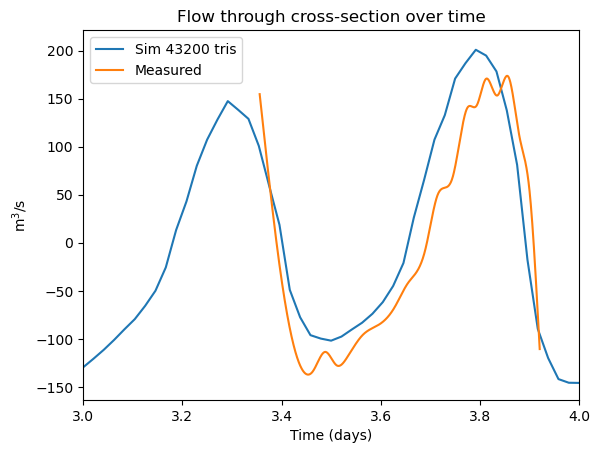

In [ ]:
verbose = False
for n, splotter in enumerate(splotters):
    t, Q = splotter.get_flow_through_cross_section(polyline, verbose=verbose) 
    plt.plot(t/3600/24, Q, label=f'Sim {num_of_triangles[n]} tris')
    pass
plt.xlabel('Time (days)')
plt.ylabel('m$^3$/s')
plt.title('Flow through cross-section over time')

model_dir = '../../model_data_sept_2003'

filename = anuga.join(model_dir,'gauge4_discharge.txt')
flow = pd.read_csv(filename, header=None, delim_whitespace=True)
#print(flow)

flow.columns = ['time', 'measured']
flow['time'] = flow['time'] /24.0 + 3.0 # convert time to days 25th Sept 2003 was at 3 days in the model time


plt.plot(flow['time'], flow['measured'], label='Measured')

plt.xlim(3,4)
plt.legend()
plt.show()

Compare stage time series at one gauge station

Simulation 0 has 577 timesteps and 43200 triangles.


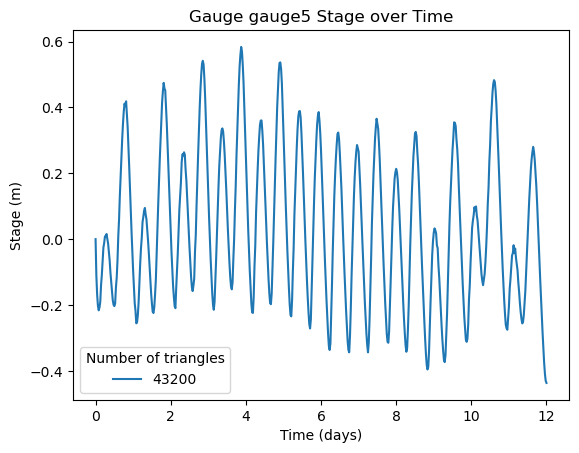

In [14]:
gid = 4  # gauge id to plot
for n,splotter in enumerate(splotters):
    print(f'Simulation {n} has {splotter.stage.shape[0]} timesteps and {splotter.stage.shape[1]} triangles.')
    plt.plot(splotter.time/3600/24, splotter.stage[:,gauge_id_list[n][gid]], label=num_of_triangles[n])

plt.legend(title='Number of triangles')
plt.title(f'Gauge {gauge_location["name"][gid]} Stage over Time')
plt.xlabel('Time (days)')
plt.ylabel('Stage (m)')
plt.show()

Compare simulation results with measured stage data

Gauge 4 measured stage data is missing gauge4


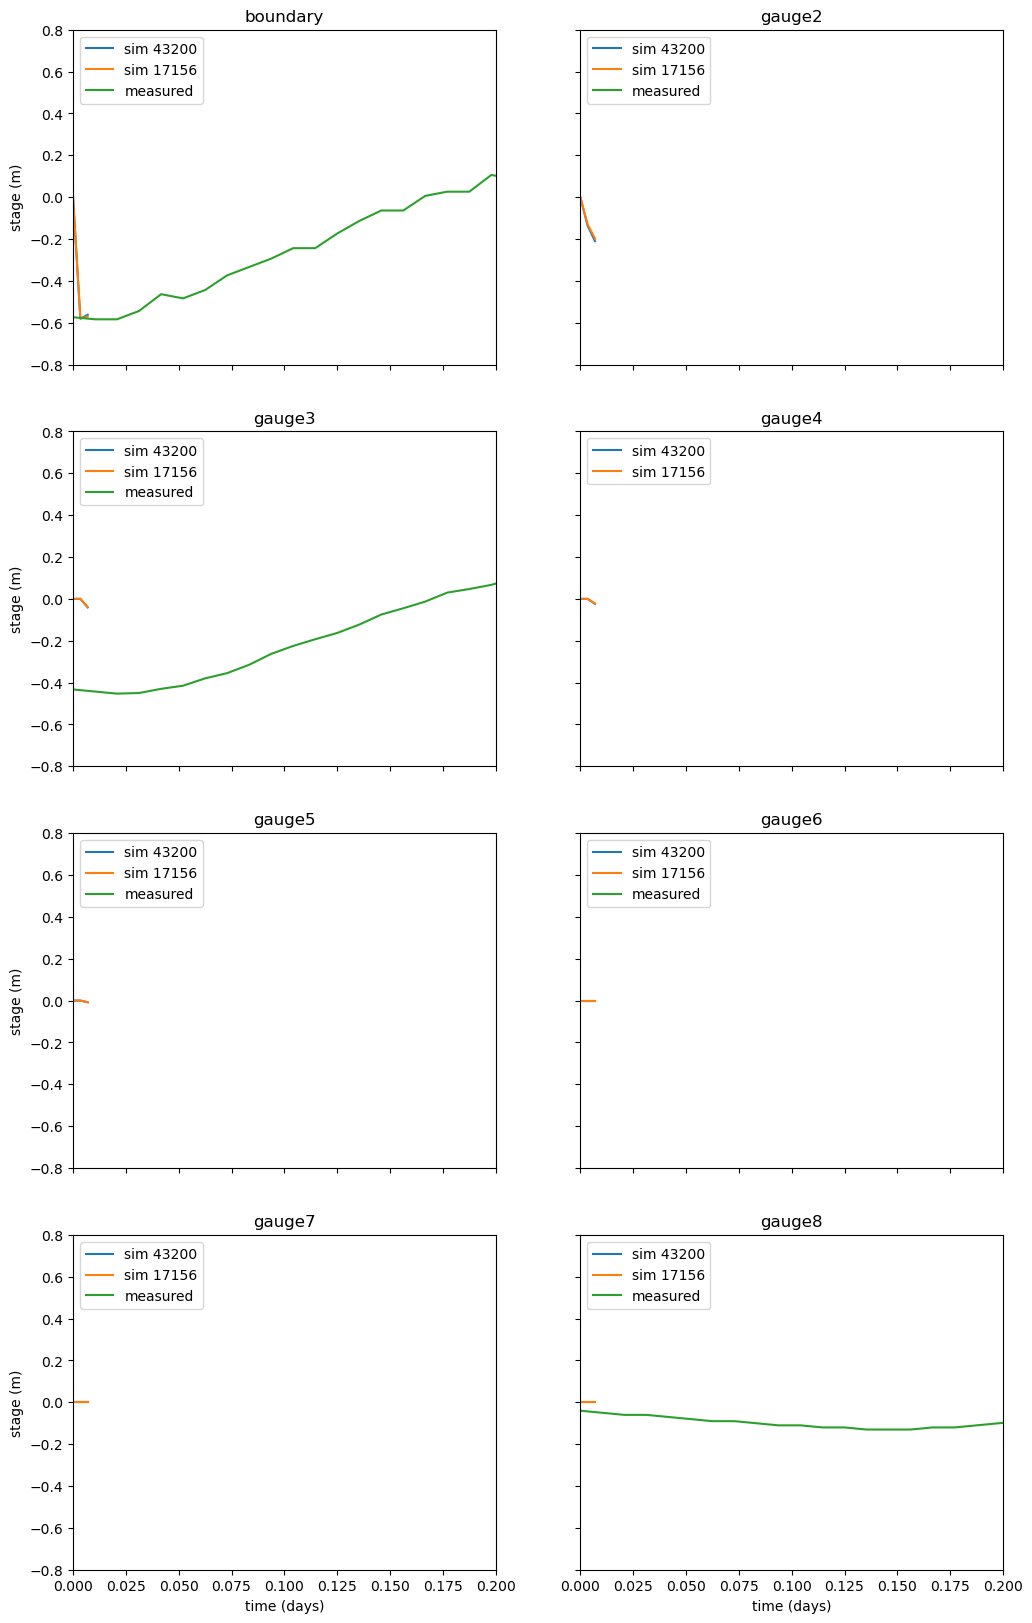

In [74]:
model_dir = '../../model_data_sept_2003'

sites = []

#for row in gauge_location.iterrows():

for index, row in gauge_location.iterrows():
    filename = anuga.join(model_dir,row['name']+'.txt')

    if row['name'] == 'gauge4':
        print(f"Gauge 4 measured stage data is missing {row['name']}")
        site = None
    else:
        site = pd.read_fwf(filename, header=None)
        site.columns = ['time', 'measured']
        site['time'] = site['time'] - 265

    sites.append(site)
        

fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6), (ax7, ax8)) = plt.subplots(4, 2, figsize=(12,20), sharex=True, sharey=True)


for i, ax in enumerate([ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8]):

    ax.set_title(gauge_location['name'][i])
    for n, (splotter, gauge_ids) in enumerate(zip(splotters, gauge_id_list)): 
        #pass
        ax.plot(splotter.time/3600/24, splotter.stage[:,gauge_ids[i]], label='sim '+str(num_of_triangles[n]))
    

    if gauge_location['name'][i] == 'gauge4':
        pass
    else:
        sites[i].plot('time','measured', ax=ax, label='measured')

    ax.legend(loc='upper left')
    ax.set_xlim(0.0, 0.2)
    ax.set_ylim(-0.8, 0.8)
    ax.set_xlabel('time (days)')
    ax.set_ylabel('stage (m)')

plt.show()    


In [13]:
from anuga.file_conversion.sww2dem import sww2dem, sww2dem_batch

sww2dem(swwfiles[0], name_out= 'domain2.asc', quantity='stage', verbose=True)

Reading from template_sept_2003_43200_weeds_20251202_202802.sww
Output directory is domain2.asc
------------------------------------------------
Statistics of SWW file:
  Name: template_sept_2003_43200_weeds_20251202_202802.sww


  Reference:
    Lower left corner: [0.000000, 0.000000]
    Start time: 1064152800.000000
  Extent:
    x [m] in [755963.812500, 761052.687500], len(x) == 129600
    y [m] in [5910260.000000, 5914386.000000], len(y) == 129600
    t [s] in [0.000000, 600.000000], len(t) == 3
  Quantities [SI units]:
    stage in [-1.484444, 0.719679]
    xmomentum in [-5.329202, 2.781847]
    ymomentum in [-8.166605, 3.287493]
    elevation in [-14.693844, 0.719679]
Slicing sww file, num points: 129600, block size: 10000
Processed values for stage are in [-0.000953, 0.719679]
Creating grid
Interpolated values are in [-9999.000000, 0.719679]
Writing domain2.prj
Writing domain2.asc
Doing row 0 of 413
Doing row 42 of 413
Doing row 84 of 413
Doing row 126 of 413
Doing row 168 of 413
Doing row 210 of 413
Doing row 252 of 413
Doing row 294 of 413
Doing row 336 of 413
Doing row 378 of 413


'domain2'

In [14]:
sww2dem_batch(swwfiles[0], quantities=['stage', 'depth'], format='asc', verbose=True)

iterate over ['template_sept_2003_43200_weeds_20251202_202802']
sww2dem: ./template_sept_2003_43200_weeds_20251202_202802.sww => ./template_sept_2003_43200_weeds_20251202_202802_stage.asc
Reading from ./template_sept_2003_43200_weeds_20251202_202802.sww
Output directory is ./template_sept_2003_43200_weeds_20251202_202802_stage.asc
------------------------------------------------
Statistics of SWW file:
  Name: ./template_sept_2003_43200_weeds_20251202_202802.sww
  Reference:
    Lower left corner: [0.000000, 0.000000]
    Start time: 1064152800.000000
  Extent:
    x [m] in [755963.812500, 761052.687500], len(x) == 129600
    y [m] in [5910260.000000, 5914386.000000], len(y) == 129600
    t [s] in [0.000000, 600.000000], len(t) == 3
  Quantities [SI units]:
    stage in [-1.484444, 0.719679]
    xmomentum in [-5.329202, 2.781847]
    ymomentum in [-8.166605, 3.287493]
    elevation in [-14.693844, 0.719679]
Slicing sww file, num points: 129600, block size: 10000
Processed values for st

['./template_sept_2003_43200_weeds_20251202_202802_stage',
 './template_sept_2003_43200_weeds_20251202_202802_depth']

In [15]:
ls

anuga_20251202_203318.log
anuga_20251205_192518.log
anuga_20251212_175928.log
anuga_20251212_182236.log
anuga_pmesh_gui.log
domain2.asc
domain2.prj
nb_compare_gauge_data.ipynb
nb_extract_gauge_data.ipynb
_plot/
project.py*
__pycache__/
run_merimbula.log
run_merimbula.py*
template_sept_2003_10785_weeds_20251202_202941_depth.asc
template_sept_2003_10785_weeds_20251202_202941_depth.prj
template_sept_2003_10785_weeds_20251202_202941_stage.asc
template_sept_2003_10785_weeds_20251202_202941_stage.prj
template_sept_2003_10785_weeds_20251202_202941.sww
template_sept_2003_17156_no_exterior_tags_weeds_20251210_140515.sww
template_sept_2003_17156_weeds_20251202_202722.sww
template_sept_2003_17156_weeds_20251210_202926.sww
template_sept_2003_19251_weeds_20251204_192701.sww
template_sept_2003_19251_weeds_20251204_193729.sww
template_sept_2003_43200_weeds_20251202_202802_depth.asc
template_sept_2003_43200_weeds_20251202_202802_depth.prj
template_sept_2003_43200_weeds_20251202_202802_stage.asc
templa